In [2]:
# imports
import sys
import os
sys.path.append(os.path.abspath('..'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.yieldcurve import YieldCurve
from src.derivatives import EuropeanCallOption, EuropeanPutOption

# Data Overview

In [3]:
from pathlib import Path
cwd = Path.cwd()
data_path = cwd / "data" / "Market_Data_BHP_prices.csv"
if not data_path.exists():
    data_path = cwd / ".." / "data" / "Market_Data_BHP_prices.csv"

df = pd.read_csv(data_path.resolve(), index_col=0, parse_dates=True, header=[0,1])

# Flatten multi-index columns and extract just BHP.AX close prices
df.columns = ['_'.join(col).strip() for col in df.columns]
close_col = [c for c in df.columns if 'Close' in c][0]
close = df[close_col].dropna()

S0 = float(close.iloc[-1])
log_returns = np.log(close / close.shift(1)).dropna()
sigma = float(log_returns.std() * np.sqrt(252))

print(f"BHP Spot Price (S0): ${S0:.2f}")
print(f"BHP Annualized Volatility (sigma): {sigma:.2%}")


BHP Spot Price (S0): $57.33
BHP Annualized Volatility (sigma): 24.93%


In [4]:
# Construct Yield Cruve from RBA Data
maturities = [0.25,2.0,3.0,5.0,10.0]
zero_rates = [0.041, 0.04536, 0.04556, 0.04621, 0.04925]
yc = YieldCurve(maturities, zero_rates)

# Sanity Checks

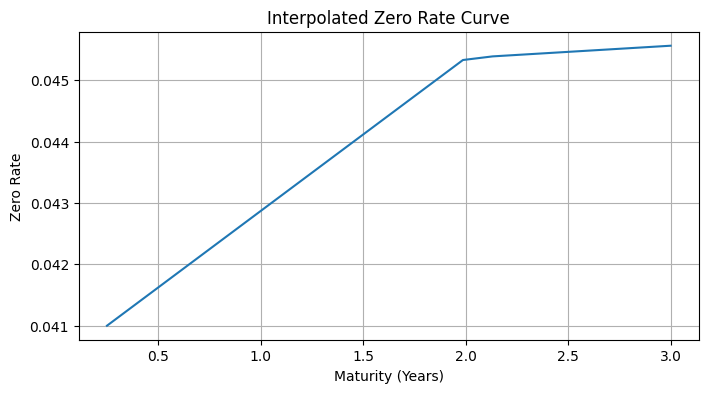

In [5]:
# sanity check on Yield Curve
test_maturities = np.linspace(0.25, 3.0, 20)
rates = [yc.get_zero_rate(T) for T in test_maturities]
dfs = [yc.get_discount_factor(T) for T in test_maturities]

plt.figure(figsize=(8,4))
plt.plot(test_maturities,rates)
plt.title("Interpolated Zero Rate Curve")
plt.xlabel("Maturity (Years)")
plt.ylabel("Zero Rate")
plt.grid(True)
plt.show()

# Option Parameters

In [7]:
# Use BHP market data
K = round(S0)  # at-the-money strike (rounded to nearest dollar)
T = 1.0  # 1 year to maturity

print(f"Option Parameters:")
print(f" S0 = ${S0:.2f} (BHP closing Price)")
print(f" K = ${K:.2f} (at-the-money strike)")
print(f" T = {T} year")
print(f" sigma = {sigma:.2%} (historical volatility)")

call = EuropeanCallOption(S0=S0, K=K, T=T, sigma=sigma, yield_curve=yc)
put = EuropeanPutOption(S0=S0, K=K, T=T, sigma=sigma, yield_curve=yc)

Option Parameters:
 S0 = $57.33 (BHP closing Price)
 K = $57.00 (at-the-money strike)
 T = 1.0 year
 sigma = 24.93% (historical volatility)


# European Call and European Put Option Prices

In [8]:
# European Call Price and European Put Price 
call_price = float(round(call.price(), 4))
put_price = float(round(put.price(), 4))

print(f"The call price is ${call_price}")
print(f"The put price is ${put_price}")

The call price is $7.0171
The put price is $4.2952


# Sense Checks

- Volatilty should increase both prices
- Time to maturity should increase both prices as well (calls more than puts)
- S0 should increase call price, decrease put price
- K should increase put price, decrease put price

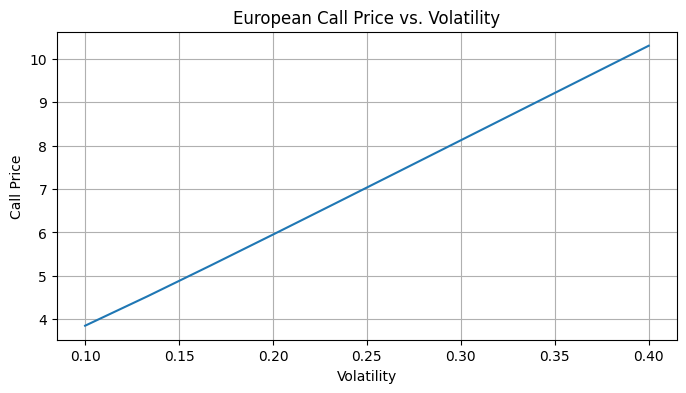

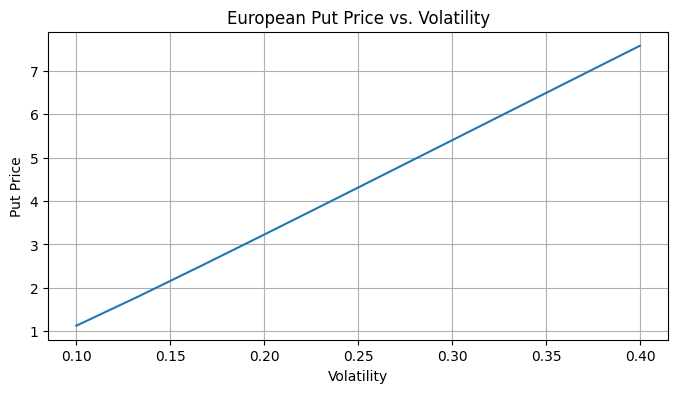

In [11]:
# Sense Checks
# 1. Volatility should increase both prices
vols = np.linspace(0.1, 0.4, 10)
call_prices = []
put_prices = []

for v in vols:
    tmp_call = EuropeanCallOption(S0=S0, K=K, T=T, sigma=v, yield_curve=yc)
    tmp_put  = EuropeanPutOption( S0=S0, K=K, T=T, sigma=v, yield_curve=yc)
    call_prices.append(tmp_call.price())
    put_prices.append(tmp_put.price())

plt.figure(figsize=(8,4))
plt.plot(vols, call_prices)
plt.title("European Call Price vs. Volatility")
plt.xlabel("Volatility")
plt.ylabel("Call Price")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(vols, put_prices)
plt.title("European Put Price vs. Volatility")
plt.xlabel("Volatility")
plt.ylabel("Put Price")
plt.grid(True)
plt.show()

# 2. Time to maturity should increase both prices
maturities = np.linspace(0.25, 3.0, 10)
call_prices_T = []
put_prices_T  = []

for t in maturities:
    tmp_call = EuropeanCallOption(S0=S0, K=K, T=t, sigma=sigma, yield_curve=yc)

In [12]:
from src.derivatives import (
    EuropeanCall, EuropeanPut,
    EuropeanCallGreeks, EuropeanPutGreeks,
    AmericanCall, AmericanPut,
    AsianCall, AsianPut
)

# European with all Greeks
call = EuropeanCallGreeks(S0=S0, K=K, T=T, sigma=sigma, yield_curve=yc)
print(call.all_greeks())

# American
am_put = AmericanPut(S0=S0, K=K, T=T, sigma=sigma, yield_curve=yc, steps=100)
print(am_put.price())

# Asian
asian_call = AsianCall(S0=S0, K=K, T=T, sigma=sigma, yield_curve=yc, simulations=10000)
print(asian_call.price())

{'delta': np.float64(0.62542903029704), 'gamma': np.float64(0.026525167757940043), 'theta': np.float64(-0.010807519616885693), 'vega': np.float64(0.2173141266785629), 'rho': np.float64(0.2883874139418789)}
4.529669756986142
3.9417089155176916


In [13]:
# ── European Call Greeks ─────────────────────────────
print("=" * 45)
print("       EUROPEAN CALL OPTION - GREEKS")
print("=" * 45)
greeks = call.all_greeks()
print(f"  {'Delta':<10} {greeks['delta']:>10.4f}   (price change per $1 move in S0)")
print(f"  {'Gamma':<10} {greeks['gamma']:>10.4f}   (rate of change of delta)")
print(f"  {'Theta':<10} {greeks['theta']:>10.4f}   (price decay per calendar day)")
print(f"  {'Vega':<10} {greeks['vega']:>10.4f}   (price change per 1% vol move)")
print(f"  {'Rho':<10} {greeks['rho']:>10.4f}   (price change per 1% rate move)")
print("=" * 45)

# ── American Put Price ───────────────────────────────
print("\n" + "=" * 45)
print("       AMERICAN PUT OPTION - PRICE")
print("=" * 45)
print(f"  {'Binomial Steps':<20} {am_put.steps:>10}")
print(f"  {'Price':<20} ${am_put.price():>9.4f}")
print(f"  {'Delta':<20} {am_put.delta():>10.4f}")
print(f"  {'Gamma':<20} {am_put.gamma():>10.4f}")
print(f"  {'Theta':<20} {am_put.theta():>10.4f}")
print(f"  {'Vega':<20} {am_put.vega():>10.4f}")
print("=" * 45)

# ── Asian Call Price ─────────────────────────────────
print("\n" + "=" * 45)
print("       ASIAN CALL OPTION - MONTE CARLO")
print("=" * 45)
print(f"  {'Simulations':<20} {asian_call.simulations:>10,}")
print(f"  {'Steps':<20} {asian_call.steps:>10}")
print(f"  {'Price':<20} ${asian_call.price():>9.4f}")
print(f"  {'Delta':<20} {asian_call.delta():>10.4f}")
print(f"  {'Gamma':<20} {asian_call.gamma():>10.4f}")
print(f"  {'Theta':<20} {asian_call.theta():>10.4f}")
print(f"  {'Vega':<20} {asian_call.vega():>10.4f}")
print("=" * 45)

       EUROPEAN CALL OPTION - GREEKS
  Delta          0.6254   (price change per $1 move in S0)
  Gamma          0.0265   (rate of change of delta)
  Theta         -0.0108   (price decay per calendar day)
  Vega           0.2173   (price change per 1% vol move)
  Rho            0.2884   (price change per 1% rate move)

       AMERICAN PUT OPTION - PRICE
  Binomial Steps              100
  Price                $   4.5297
  Delta                   -0.3967
  Gamma                    0.0631
  Theta                   -0.0050
  Vega                     0.2173

       ASIAN CALL OPTION - MONTE CARLO
  Simulations              10,000
  Steps                       252
  Price                $   3.9417
  Delta                    0.5852
  Gamma                    0.0499
  Theta                   -0.0058
  Vega                     0.1222
